In [43]:
import pandas as pd
import numpy as np
import shutil
import os
import random
from PIL import Image
from datasets import load_dataset

In [44]:
plots = pd.read_json("../data/annotations.json")

print("Plots Dataset size :", len(plots))
plots.head()

Plots Dataset size : 33657


,models,type,general_figure_info,image_index
0,"[{'name': 'Goods and services', 'color': '#F0E...",dot_line,{'title': {'text': 'Payments made towards prim...,0
1,"[{'name': 'Arms exports', 'color': '#FFFF00', ...",dot_line,{'title': {'text': 'Arm exports and imports in...,1
2,"[{'name': 'Infant', 'color': '#191970', 'label...",dot_line,{'title': {'text': 'Mortality rates in Marshal...,2
3,"[{'name': 'Female', 'color': '#D2B48C', 'label...",dot_line,{'title': {'text': 'Percentage of repeaters in...,3
4,"[{'name': 'US$', 'color': '#B8860B', 'label': ...",dot_line,{'title': {'text': 'Total resource balance of ...,4


**Filtro el dataset para quedarme con las visualizaciones single-plot, elimino los hbar plots y renombro los tipos**

In [45]:
single_plots = plots[plots['models'].apply(lambda x: len(x) == 1)].copy()
single_plots.loc[:, "type"] = single_plots["type"].map({"dot_line": "point", "vbar_categorical": "bar", "line": "line"})
single_plots = single_plots.dropna(subset=["type"])

print("Single-plots Dataset size :", len(single_plots))
single_plots.head()

Single-plots Dataset size : 4179


,models,type,general_figure_info,image_index
4435,"[{'name': 'Secure Internet servers', 'color': ...",point,{'title': {'text': 'Number of secure servers i...,4435
4436,"[{'name': 'Communications', 'color': '#FFA07A'...",point,"{'y_axis': {'minor_ticks': {'values': [0, 1, 2...",4436
4437,"[{'name': 'Armed forces personnel', 'color': '...",point,{'title': {'text': 'Total onduty military pers...,4437
4438,[{'name': 'Government expenditure per tertiary...,point,{'title': {'text': 'Government expenditure per...,4438
4439,"[{'name': 'Tax payments', 'color': '#6B8E23', ...",point,"{'y_axis': {'minor_ticks': {'values': [0, 1, 2...",4439


In [46]:
def get_vega(df, index):
    
    ''' Get vega code from a PlotQA DataFrame entry at index '''

    mark_type = df["type"][index]

    x_name = df["general_figure_info"][index]["x_axis"]["label"]["text"]
    y_name = df["general_figure_info"][index]["y_axis"]["label"]["text"]

    y_values = [np.round(y, 2) for y in df["models"][index][0]["y"]]
    
    x_values = single_plots["general_figure_info"][index]["x_axis"]["major_labels"]["values"]
    midpoint = len(x_values) // 2
    x_values = x_values[:midpoint]

    vega = {"mark": mark_type,
            "encoding": {
                "x": {"field": x_name, "type": "ordinal"},
                "y": {"field": y_name, "type": "quantitative"}
            },
            "data": {
                "values": [
                    {"x": x, "y": y} for x,y in zip(x_values, y_values)
                ]
            }
        }

    return vega

In [47]:
index = single_plots.sample().index[0]
get_vega(single_plots, index)

{'mark': 'bar',
 'encoding': {'x': {'field': 'Country', 'type': 'ordinal'},
  'y': {'field': '% of women ages 15-49', 'type': 'quantitative'}},
 'data': {'values': [{'x': 'Japan', 'y': 64.5},
   {'x': 'Kuwait', 'y': 34.6},
   {'x': 'Mali', 'y': 4.7},
   {'x': 'Mexico', 'y': 52.7},
   {'x': 'Morocco', 'y': 35.9},
   {'x': 'Paraguay', 'y': 44.8}]}}

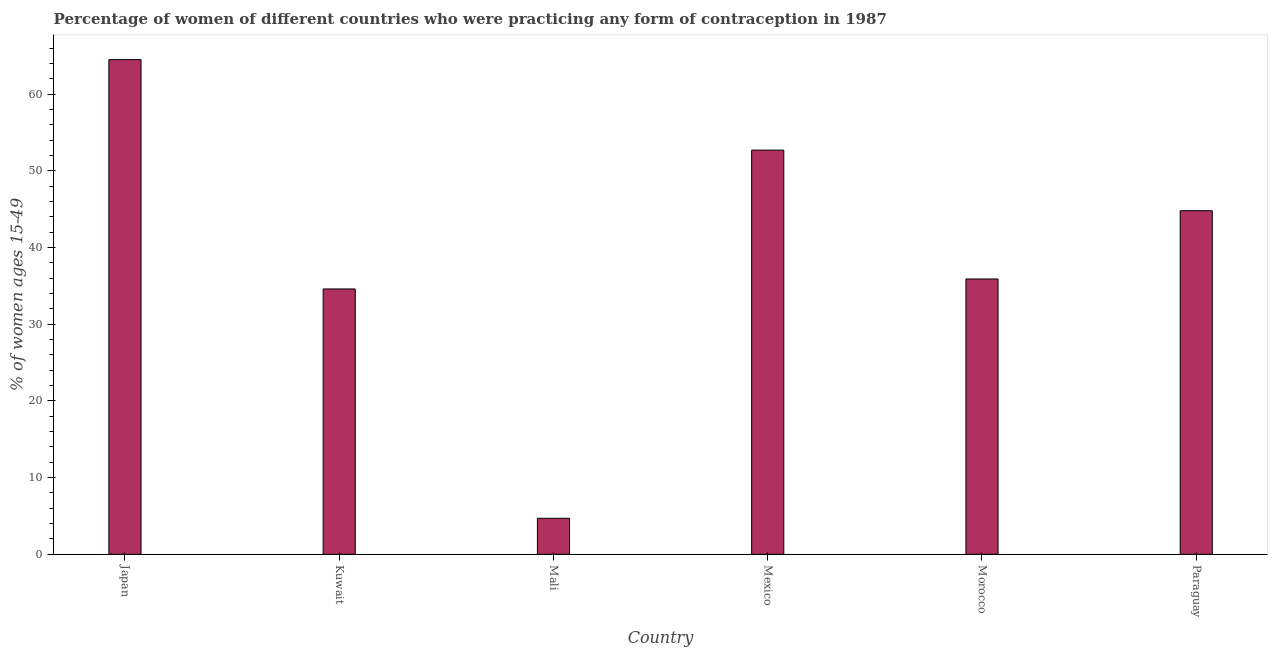

In [48]:
Image.open("../plotqa/png/"+ str(index) +".png")

In [52]:
def erase_files(path):

    for filename in os.listdir(path):

        file_path = os.path.join(path, filename)

        try:
            if os.path.isfile(file_path): os.remove(file_path)
        except Exception as e:
            print(f"Error deleting {file_path}: {e}")

def copy_file(filename, src_dir, dest_dir):
    
    source_path = os.path.join(src_dir, filename)
    destination_path = os.path.join(dest_dir,filename)

    if os.path.exists(source_path):
        try:
            shutil.copy(source_path, destination_path)
        except IOError as e:
            print(f"Failed to copy {filename}: {e}")
    else:
        print(f"File {filename} does not exist in the source directory.")

def generate_dataset(path, df, n_samples):
    
    np.random.seed(42)
    random.seed(42)

    erase_files(path)

    indexes = list(df.sample(n_samples).index)
    metadata = [['file_name','text']]

    for i in indexes:
        
        copy_file(str(i) + ".png", "../plotqa/png", "datasets/plotqa/test")

        vega_str = '"' + str(get_vega(df, i)) + '"'
        metadata.append([str(i) + ".png", vega_str])

    np.savetxt(path + "/metadata.csv", metadata, delimiter = ',', fmt = '% s')

In [55]:
generate_dataset("datasets/plotqa/test", single_plots, n_samples = 1)

In [56]:
dataset = load_dataset("imagefolder", data_dir = "datasets/plotqa")
dataset.push_to_hub("martinsinnona/plotqa")

Generating test split: 0 examples [00:00, ? examples/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

CommitInfo(commit_url='https://huggingface.co/datasets/martinsinnona/plotqa/commit/90c2c1350d617f254548acc62b073e17cc3901d5', commit_message='Upload dataset', commit_description='', oid='90c2c1350d617f254548acc62b073e17cc3901d5', pr_url=None, pr_revision=None, pr_num=None)